# 50 Startups Dataset - Statistical Analysis

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load dataset
try:
    df = pd.read_csv('../PANDA/50_Startups.csv')
except:
    np.random.seed(42)
    df = pd.DataFrame({
        'R&D Spend': np.random.uniform(60000, 155000, 50),
        'Administration': np.random.uniform(50000, 150000, 50),
        'Marketing Spend': np.random.uniform(13000, 150000, 50),
        'Profit': np.random.uniform(40000, 250000, 50)
    })

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset Shape: (50, 4)

First few rows:
       R&D Spend  Administration  Marketing Spend         Profit
0   95581.311290   146958.462776     17305.798439  230735.836053
1  150317.859109   127513.282336    100188.226343   90307.997040
2  129539.424472   143949.894156     56066.769407   70427.923139
3  116872.555999   139482.735043     82674.184690  142785.079658
4   74821.770842   109789.997881    137336.606928  246986.595363



A. DESCRIPTIVE STATISTICS

Mean:
R&D Spend          102362.770917
Administration      99443.758236
Marketing Spend     78527.088676
Profit             148646.341083
dtype: float64

Standard Deviation:
R&D Spend          27443.904093
Administration     30684.151020
Marketing Spend    40762.884016
Profit             60962.813806
dtype: float64

Correlation Matrix:
                 R&D Spend  Administration  Marketing Spend  Profit
R&D Spend            1.000           0.062           -0.122   0.037
Administration       0.062           1.000           -0.111   0.039
Marketing Spend     -0.122          -0.111            1.000  -0.208
Profit               0.037           0.039           -0.208   1.000


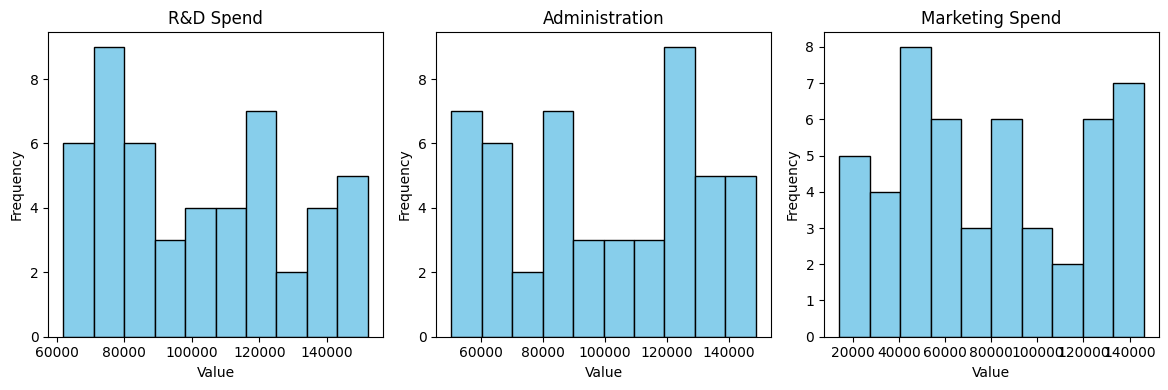

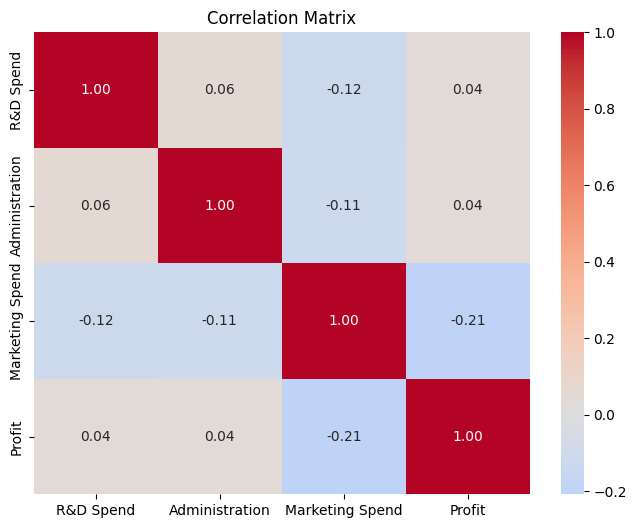

In [10]:
# A. DESCRIPTIVE STATISTICS
print("\n" + "="*60)
print("A. DESCRIPTIVE STATISTICS")
print("="*60)

print("\nMean:")
print(df.mean())

print("\nStandard Deviation:")
print(df.std())

print("\nCorrelation Matrix:")
print(df.corr().round(3))

# Plot distributions
plt.figure(figsize=(12, 4))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(1, 3, i+1)
    plt.hist(df[col], bins=10, edgecolor='black', color='skyblue')
    plt.title(f'{col}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


B. PROFIT PREDICTION

Model Coefficients:
  R&D Spend: 0.28
  Administration: 0.24
  Marketing Spend: -0.28
  Intercept: 120127.54

Model Performance (Test Set):
  R² Score: -0.2884
  RMSE: 62819.08
  MAE: 56886.35


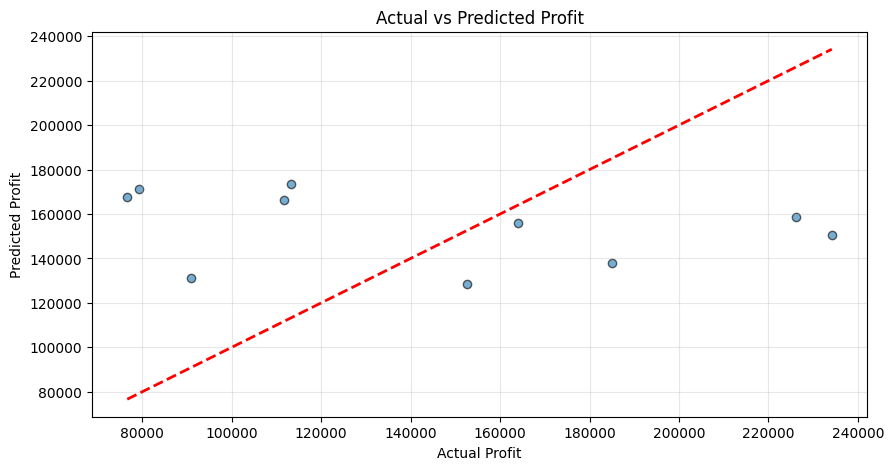

In [11]:
# B. PROFIT PREDICTION (Linear Regression)
print("\n" + "="*60)
print("B. PROFIT PREDICTION")
print("="*60)

# Prepare data
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"  Intercept: {model.intercept_:.2f}")

print("\nModel Performance (Test Set):")
print(f"  R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred):.2f}")

# Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Profit')
plt.grid(alpha=0.3)
plt.show()


C. HYPOTHESIS TESTING - CATEGORICAL ASSOCIATION

Test: R&D Spend vs Profit
H₀: R&D Spend and Profit are independent
H₁: R&D Spend and Profit are associated

Contingency Table:
Profit_Level  Low  High
RD_Level               
Low            12    16
High           10    12

Chi-Square Statistic: 0.0000
P-value: 1.0000
Degrees of Freedom: 1
Significance Level (α): 0.05

✗ FAIL TO REJECT Null Hypothesis
  → No significant association between R&D Spend and Profit


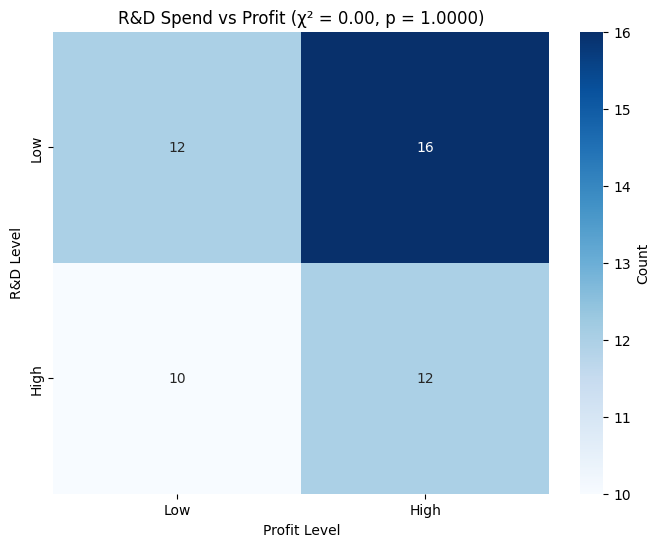

In [12]:
# C. HYPOTHESIS TESTING (Chi-Square Test)
print("\n" + "="*60)
print("C. HYPOTHESIS TESTING - CATEGORICAL ASSOCIATION")
print("="*60)

# Create categorical variables
df_cat = df.copy()
df_cat['RD_Level'] = pd.cut(df['R&D Spend'], bins=2, labels=['Low', 'High'])
df_cat['Profit_Level'] = pd.cut(df['Profit'], bins=2, labels=['Low', 'High'])

# Chi-Square Test
print("\nTest: R&D Spend vs Profit")
print("H₀: R&D Spend and Profit are independent")
print("H₁: R&D Spend and Profit are associated")

contingency = pd.crosstab(df_cat['RD_Level'], df_cat['Profit_Level'])
print("\nContingency Table:")
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Significance Level (α): 0.05")

if p_value < 0.05:
    print("\n✓ REJECT Null Hypothesis")
    print("  → R&D Spend and Profit ARE statistically associated")
else:
    print("\n✗ FAIL TO REJECT Null Hypothesis")
    print("  → No significant association between R&D Spend and Profit")

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.title(f'R&D Spend vs Profit (χ² = {chi2:.2f}, p = {p_value:.4f})')
plt.xlabel('Profit Level')
plt.ylabel('R&D Level')
plt.show()